# **International Arrivals to Vietnam Forecasting**
---
## **1. Problem Introduction**

### **a. Definition**
**Objective:** Predict the total number of international tourist arrivals to Vietnam on a monthly basis from January 2008 to February 2026

**Purpose:**

* plan tourism infrastructure
* forecast revenue for the service sector
* allocate communication and marketing resources
* identify recovery trends after major events (COVID-19)

**Technical representation:** Time Series Forecasting Problem

**Goal:** Model the relationship between the target variable (`international_arrivals_total`) and the explanatory variables (`date_month_start`, `positive_event_flag` and `negative_event_flag` in `exogenous_arrivals.csv`)

### **b. Methodology:** **Linear Regression** for time series forecasting
**First stage:** Linear Regression with **Gradient Descent** (univariate baseline)

**Next stage:** apply **Normal Equation** (multivariate model)

**Purpose:** compare optimization methods, extend the model with more explanatory variables while maintaining computational efficiency

### **c. Dataset**

`endogenous_arrivals.csv`: monthly dates, total arrivals

`exogenous_arrivals.csv`: binary flags for positive, negative events

`combined_arrivals.csv`: merged dataset, utilized in the final Normal Equation model

---
## **2. Preprocessing Data**

### **a. Import Library**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### **b. Preprocessing Data, Data Visualization**

#### **b.1. Load, Read, Combine Data**

In [2]:
#1. READ AND COMBINE DATA
df_endo = pd.read_csv('endogenous_arrivals.csv')
df_endo.head()

,date_month_start,international_arrivals_total
0,2008-01-01,399556
1,2008-02-01,411032
2,2008-03-01,414332
3,2008-04-01,395900
4,2008-05-01,366387


In [3]:
file_exo = 'exogenous_arrivals.csv'
df_exo = pd.read_csv(file_exo)

#Merge data base on mutual 'date_month_start' column, then convert into new file
df_comb = pd.merge(df_endo, df_exo[['date_month_start', 'positive_event_flag', 'negative_event_flag']], on='date_month_start', how = 'left')
df_comb.to_csv('combined_arrivals.csv', index=False)
df_comb.head()

,date_month_start,international_arrivals_total,positive_event_flag,negative_event_flag
0,2008-01-01,399556,1,0
1,2008-02-01,411032,1,0
2,2008-03-01,414332,0,1
3,2008-04-01,395900,1,0
4,2008-05-01,366387,1,0


In [4]:
#Initialize base time index t = 0, 1, 2...
df_comb['t'] = np.arange(len(df_comb))
df_comb['date_month_start'] = pd.to_datetime(df_comb['date_month_start'])

#### **b.2. EDA (Exploratory Data Analysis) to detect anomalies**

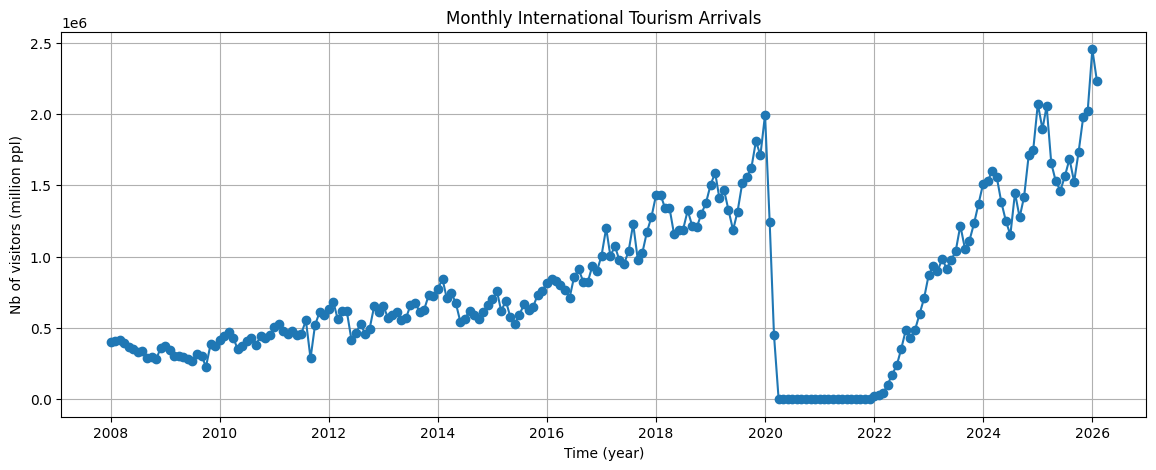

In [5]:
#2. ORIGINAL DATA VISUALIZATION TO DETECT ANOMALIES
plt.figure(figsize = (14, 5))
plt.plot(df_comb['date_month_start'], 
        df_comb['international_arrivals_total'], 
        marker = 'o', linestyle = '-')
plt.title("Monthly International Tourism Arrivals")
plt.xlabel("Time (year)")
plt.ylabel("Nb of visitors (million ppl)")
plt.grid(True)
plt.show()

From the graph: period 2020 - 2021: a sudden fall-off, no longer represent the previous normal trend

**Correlation Matrix (Heatmap)**

To check the correlation between target variable and exogenous event flags

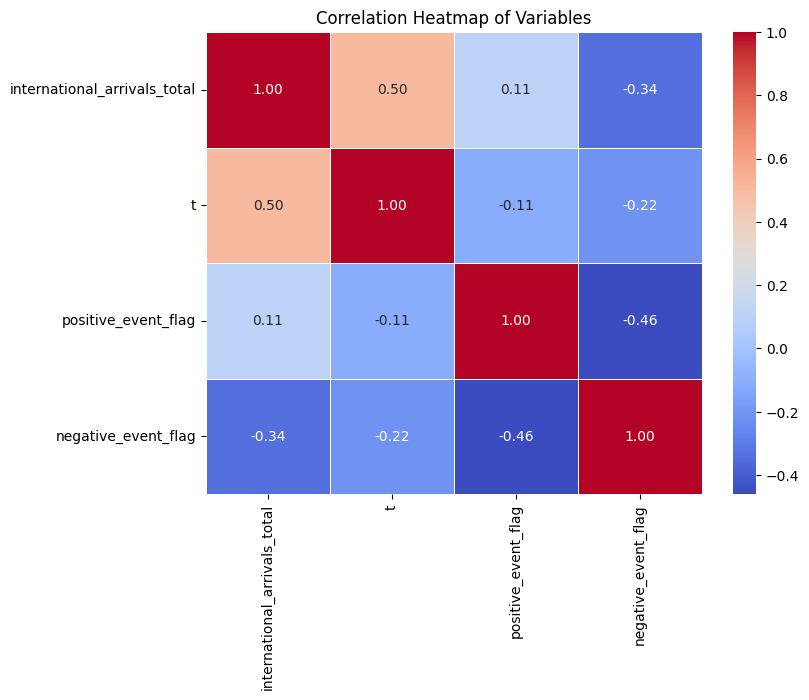

In [6]:
cols_for_corr = ['international_arrivals_total', 't', 'positive_event_flag', 'negative_event_flag']
corr_matrix = df_comb[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Variables")
plt.show()

`t` and `positive/negative_event_flag` have a certain correlation with total nb of `international_arrivals`

Moreover, there is no excessive correlation => can use these 3 variables in Multiple Linear Regression model


#### **b.3. Train - Test split**

We have to split the data in to: 

- Train Set (2008 - 2019): pre-pandemic stabilization phase

- Covid Set (2020 - 2021): completely remove from training

- Validation Set (2022 - 2023): beginning of post-pandemic recovery

- Test Set (2024 - 2/2026): return of stable travel

In [7]:
#3. SPLIT INTO TRAIN - COVID - VALID - TEST DATA
#Create timelines for each dataset
train_start = '2008-01-01'
train_end = '2019-12-31'

covid_start = '2020-01-01'
covid_end = '2021-12-31'

val_start = '2022-01-01'
val_end = '2023-12-31'

test_start = '2024-01-01'
test_end = '2026-02-28'

    #Split data based on time conditions
    #copy(): avoid pandas warnings when creating new columns
#Train data (2008 - 2019)
df_train = df_comb[(df_comb['date_month_start'] >= train_start) & (df_comb['date_month_start'] <= train_end)].copy()
#Covid data (2020 - 2021) - NOT TO TRAIN DATA
df_covid = df_comb[(df_comb['date_month_start'] >= covid_start) & (df_comb['date_month_start'] <= covid_end)].copy()
#Validation data (2022 - 2023)
df_val = df_comb[(df_comb['date_month_start'] >= val_start) & (df_comb['date_month_start'] <= val_end)].copy()
#Test data (2024 - 2026)
df_test = df_comb[(df_comb['date_month_start'] >= test_start) & (df_comb['date_month_start'] <= test_end)].copy()

#Print to check len of each dataset
split_summary_df = pd.DataFrame({
    'dataset': ['Train', 'COVID', 'Validation', 'Test'],
    'start': [df_train['date_month_start'].min(), df_covid['date_month_start'].min(), df_val['date_month_start'].min(), df_test['date_month_start'].min()],
    'end':[df_train['date_month_start'].max(), df_covid['date_month_start'].max(), df_val['date_month_start'].max(), df_test['date_month_start'].max()],
    'nb_of_months': [len(df_train), len(df_covid), len(df_val), len(df_test)]
})
display(split_summary_df)

,dataset,start,end,nb_of_months
0,Train,2008-01-01,2019-12-01,144
1,COVID,2020-01-01,2021-12-01,24
2,Validation,2022-01-01,2023-12-01,24
3,Test,2024-01-01,2026-02-01,26


#### **b.4. Data Normalization - Scaling**

In [8]:
#4. NORMALIZE ON TRAIN SET 
t_mean, t_std = df_comb['t'].mean(), df_comb['t'].std()
y_mean, y_std = df_comb['international_arrivals_total'].mean(), df_comb['international_arrivals_total'].std()
pos_mean, pos_std = df_comb['positive_event_flag'].mean(), df_comb['positive_event_flag'].std()
neg_mean, neg_std = df_comb['negative_event_flag'].mean(), df_comb['negative_event_flag'].std()

#in case std = 0 get error / 0
if pos_std == 0: pos_std = 1
if neg_std == 0: neg_std = 1

#==================================================
#5. SCALE FUNCTION FOR 3 DATASETS (EXCEPT COVID)
def scale_datasets(df):
    #eg for train dataset
    df['t_scaled'] = (df['t'] - t_mean) / t_std
    df['y_scaled'] = (df['international_arrivals_total'] - y_mean) / y_std
    df['pos_scaled'] = (df['positive_event_flag'] - pos_mean) / pos_std
    df['neg_scaled'] = (df['negative_event_flag'] - neg_mean) / neg_std
    return df

#apply for all
df_train = scale_datasets(df_train)
df_val = scale_datasets(df_val)
df_test = scale_datasets(df_test)

**Create matrix X, Y in Train - Validation - Test Set, add bía column 1**

In [9]:
#6. CREATE MATRIX X, Y IN NUMPY
#Gradient Descent (only t_scaled)
X_train_endo = np.c_[np.ones(len(df_train)), df_train['t_scaled'].values]
Y_train = df_train['y_scaled'].values.reshape(-1, 1)

X_val_endo = np.c_[np.ones(len(df_val)), df_val['t_scaled'].values]
Y_val = df_val['y_scaled'].values.reshape(-1, 1)

X_test_endo = np.c_[np.ones(len(df_test)), df_test['t_scaled'].values]
Y_test = df_test['y_scaled'].values.reshape(-1, 1)

#Normal Equation (t_scaled, pos_scaled, neg_scaled)
X_train_comb = np.c_[np.ones(len(df_train)),
                     df_train['t_scaled'].values,
                     df_train['pos_scaled'].values,
                     df_train['neg_scaled'].values]

X_val_comb = np.c_[np.ones(len(df_val)),
                     df_val['t_scaled'].values,
                     df_val['pos_scaled'].values,
                     df_val['neg_scaled'].values]

X_test_comb = np.c_[np.ones(len(df_test)),
                     df_test['t_scaled'].values,
                     df_test['pos_scaled'].values,
                     df_test['neg_scaled'].values]

**Check matrix shape**

In [10]:
#7. PRINT TO CHECK
print("\n--- Train matrix size for Gradient Descent ---")
print("X_train_endo shape:", X_train_endo.shape)
print("Y_train shape:", Y_train.shape)

print("\n--- Train matrix size for Normal Equation ---")
print("X_train_comb shape:", X_train_comb.shape)
print("Y_train shape:", Y_train.shape)

print("\n--- Validation matrix size ---")
print("X_val_endo shape:", X_val_endo.shape)
print("X_val_comb shape:", X_val_comb.shape)
print("Y_val shape:", Y_val.shape)

print("\n--- Test matrix size ---")
print("X_test_endo shape:", X_test_endo.shape)
print("X_test_comb shape:", X_test_comb.shape)
print("Y_test shape:", Y_test.shape)


--- Train matrix size for Gradient Descent ---
X_train_endo shape: (144, 2)
Y_train shape: (144, 1)

--- Train matrix size for Normal Equation ---
X_train_comb shape: (144, 4)
Y_train shape: (144, 1)

--- Validation matrix size ---
X_val_endo shape: (24, 2)
X_val_comb shape: (24, 4)
Y_val shape: (24, 1)

--- Test matrix size ---
X_test_endo shape: (26, 2)
X_test_comb shape: (26, 4)
Y_test shape: (26, 1)


---

## **3. Training Model**

### **a. Gradient Descent**

In [11]:
def init(dim):
    return np.random.rand(dim, 1)
def predict_Y(theta, X):
    return np.dot(X, theta)

def get_cost(Y, Y_hat):
    m = len(Y)
    cost = (1/(2*m)) * np.sum((Y_hat - Y) ** 2)
    return cost

def run_gradient_descent(X, Y, theta, alpha, iterations):
    m = len(Y)
    cost_history = []

    for i in range (iterations):
        Y_hat = predict_Y(theta, X)
        gradient = (1/m) * np.dot(X.T, (Y_hat - Y))
        theta = theta - alpha * gradient
        new_Y_hat = predict_Y(theta, X)
        cost = get_cost(Y, new_Y_hat)
        cost_history.append(cost)
    return theta, cost_history


**Run Gradient Descent**

In [12]:
alpha = 0.01
iterations = 1000
theta_endo = init(X_train_endo.shape[1])

print("\n---Gradient Descent---")
theta_endo, cost_history = run_gradient_descent(X_train_endo, Y_train, theta_endo, alpha, iterations)
print("X_train shape:", X_train_endo.shape)
print("Y_train shape:", Y_train.shape)
print("Theta shape:", theta_endo.shape)
print("Optimized Theta:", theta_endo.flatten())


---Gradient Descent---
X_train shape: (144, 2)
Y_train shape: (144, 1)
Theta shape: (2, 1)
Optimized Theta: [0.46888469 0.94025708]


**Cost Function**

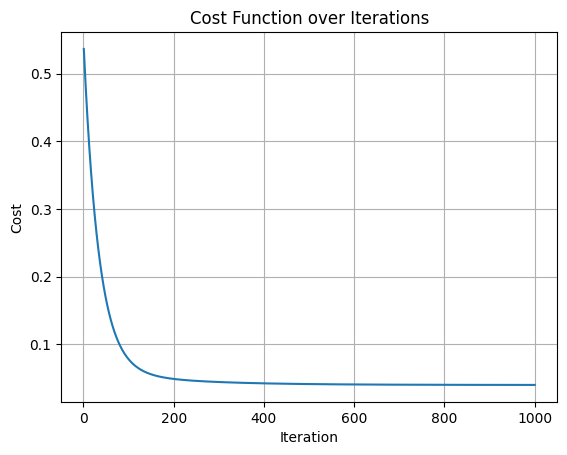

In [13]:
plt.plot(range(1, iterations + 1), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function over Iterations")
plt.grid(True)
plt.show()

The cost decreases quickly at first and then stabilizes, which indicates that Gradient Descent converges well

=> The model has reached its optimal point (gradient close to 0)

### **b. Using Normal Equation, with more variables**

In [14]:
def normal_equation(X, Y):
    #theta = (X^TX)^-1 X^T Y
    XTX = np.dot(X.T, X)
    XTX_inv = np.linalg.inv(XTX)
    XTY = np.dot(X.T, Y)
    theta = np.dot(XTX_inv, XTY)
    return theta

**Run Normal Equation**

In [15]:
print("\n---Normal Equation---")
theta_comb = normal_equation(X_train_comb, Y_train)
print("Normalized Theta:", theta_comb.flatten())


---Normal Equation---
Normalized Theta: [ 0.4841505   0.96150976  0.04438242 -0.02794319]


---

## **4. Model Comparison via Evaluation**

In [16]:
def evaluate_model(Y, Y_hat):
    mae = np.mean(np.abs(Y - Y_hat))
    mse = np.mean((Y - Y_hat) ** 2)
    rmse = np.sqrt(mse)

    ss_tot = np.sum((Y - np.mean(Y)) ** 2)
    ss_res = np.sum((Y - Y_hat) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    return mae, mse, rmse, r2

#Convert from scaled values into original data
def inverse_y(y_scaled):
    return y_scaled * y_std + y_mean

**Gradient Descent Evaluation**

In [17]:
Y_train_pred_endo = predict_Y(theta_endo, X_train_endo)
Y_val_pred_endo = predict_Y(theta_endo, X_val_endo)
Y_test_pred_endo = predict_Y(theta_endo, X_test_endo)

gd_train = evaluate_model(Y_train, Y_train_pred_endo)
gd_val = evaluate_model(Y_val, Y_val_pred_endo)
gd_test = evaluate_model(Y_test, Y_test_pred_endo)

**Normal Equation Evaluation**

In [18]:
Y_train_pred_comb = predict_Y(theta_comb, X_train_comb)
Y_val_pred_comb = predict_Y(theta_comb, X_val_comb)
Y_test_pred_comb = predict_Y(theta_comb, X_test_comb)

ne_train = evaluate_model(Y_train, Y_train_pred_comb)
ne_val = evaluate_model(Y_val, Y_val_pred_comb)
ne_test = evaluate_model(Y_test, Y_test_pred_comb)

**Scaled data Comparison**

**Actual - Predict Visualization in Train, Validation, Test Set - GRADIENT DESCENT - NORMAL EQUATION**

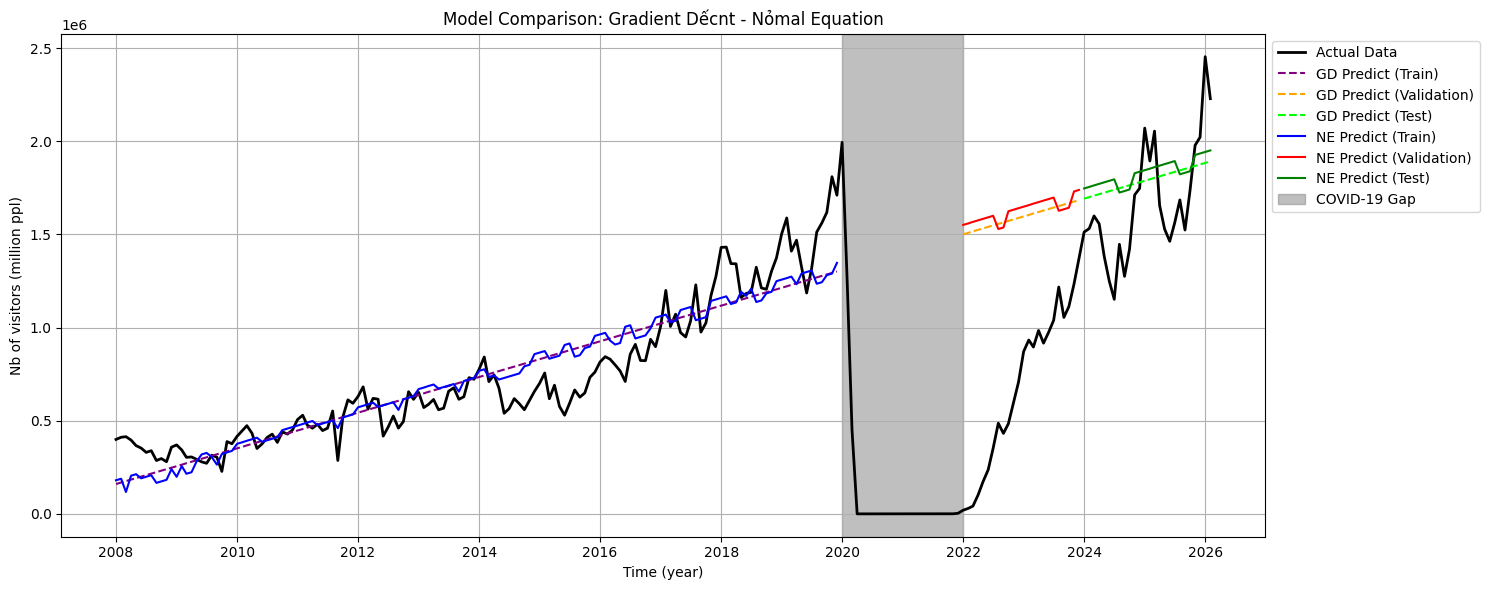

In [19]:
df_comb['date_month_start'] = pd.to_datetime(df_comb['date_month_start'])
plt.figure(figsize=(15, 6))

#1. Actual data
plt.plot(
    df_comb['date_month_start'],
    df_comb['international_arrivals_total'],
    color = 'black',
    linewidth = 2,
    label = 'Actual Data'
)

#2. Inverse scaled values into real numbers
Y_train_true = inverse_y(Y_train)
Y_val_true = inverse_y(Y_val)
Y_test_true = inverse_y(Y_test)

Y_train_pred_endo_true = inverse_y(Y_train_pred_endo)
Y_val_pred_endo_true = inverse_y(Y_val_pred_endo)
Y_test_pred_endo_true = inverse_y(Y_test_pred_endo)

Y_train_pred_comb_true = inverse_y(Y_train_pred_comb)
Y_val_pred_comb_true = inverse_y(Y_val_pred_comb)
Y_test_pred_comb_true = inverse_y(Y_test_pred_comb)

#3. Plot GRADIENT DESCENT
plt.plot(df_train['date_month_start'], Y_train_pred_endo_true, color = 'purple', linestyle = '--', label = 'GD Predict (Train)')
plt.plot(df_val['date_month_start'], Y_val_pred_endo_true, color = 'orange', linestyle = '--', label = 'GD Predict (Validation)')
plt.plot(df_test['date_month_start'], Y_test_pred_endo_true, color = 'lime', linestyle = '--', label = 'GD Predict (Test)')

#4. Plot NORMAL EQUATION
plt.plot(df_train['date_month_start'], Y_train_pred_comb_true, color = 'blue', label = 'NE Predict (Train)')
plt.plot(df_val['date_month_start'], Y_val_pred_comb_true, color = 'red', label = 'NE Predict (Validation)')
plt.plot(df_test['date_month_start'], Y_test_pred_comb_true, color = 'green', label = 'NE Predict (Test)')

#5. Color the 2020 - 2022 period (COVID 19) - skip this data
plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-12-31'), color = 'gray', alpha = 0.5, label = 'COVID-19 Gap')

plt.title("Model Comparison: Gradient Dếcnt - Nỏmal Equation")
plt.xlabel("Time (year)")
plt.ylabel("Nb of visitors (million ppl)")
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

**=> Conclusion:** This visually proves that our Linear Regression models are currently too simple (underfitting). The added binary event flags are not sufficient to model the extreme complexity and strong seasonal fluctuations of this time series.

**Convert into Number of Visitors**

In [20]:
print("\n--- EVALUATION IN ORIGINAL UNITS (NB OF VISITORS) ---")
print("\n[VALIDATION SET]")
print("Gradient Descent Model:")
evaluate_model(Y_val_true, Y_val_pred_endo_true)
print("Normal Equation Model:")
evaluate_model(Y_val_true, Y_val_pred_comb_true)

print("\n[TEST SET]")
print("Gradient Descent Model:")
evaluate_model(Y_test_true, Y_test_pred_endo_true)
print("Normal Equation Model:")
evaluate_model(Y_test_true, Y_test_pred_comb_true)


--- EVALUATION IN ORIGINAL UNITS (NB OF VISITORS) ---

[VALIDATION SET]
Gradient Descent Model:
Normal Equation Model:

[TEST SET]
Gradient Descent Model:
Normal Equation Model:


(np.float64(266659.9041048003),
 np.float64(94985880346.8864),
 np.float64(308197.7941953615),
 np.float64(-9.432166814238307e-05))

**Comparison:** 

* MAE, MSE, RMSE: the smaller value, the better performance

* R^2: the higher value, the better explanatory power

* To understand the real-world impact, the MAE and RMSE are also interpreted in terms of actual visitor numbers

**1. Train Set:** Normal Equation fits the training data slightly better

**2. Validation Set:** Gradient Descent generalizes slightly better on the validation set

* The validation period is highly unstable due to initial post-COVID recovery. Both models struggle heavily (negative R²), but GD's MAE is off by roughly **932,716 visitors/month**, which is slightly better than NE's error of **950,532 visitors/month**

**3. Test Set:** Almost equal

* GD very slight better RMSE (308,031 vs 308,197) and R² (0.0010 vs -0.0001)

* NE very slight better MAE (266,659 vs 268,624). This means that on avg, the NE model's absolute monthly prediction is closer to the real number by a small margin of **1,965 visitors**

* difference is very small

=> Both models perform almost identically on test set

==> **Overall, the additional exogenous variables (`positive_event_flag` and `negative_event_flag`) contribute only limited predictive value in current linear formulation**

**IN GENERAL**

Both models capture the long-term trend, but they do not model the post-COVID recovery period well. 

This is reflected in the poor validation performance and the negative R² values. 

The results suggest that the current linear features are still too simple (**Underfitting**) to capture seasonal fluctuations and post-COVID recovery dynamics.

POV: The test-set MAE of more than **266,000 visitors/month** suggests that more expressive features or more advanced non-linear models should be considered in future work.

---

### **Residual Analysis (Normal Equation on Test Set)**

*To deeply understand the limitations of this Linear Model*

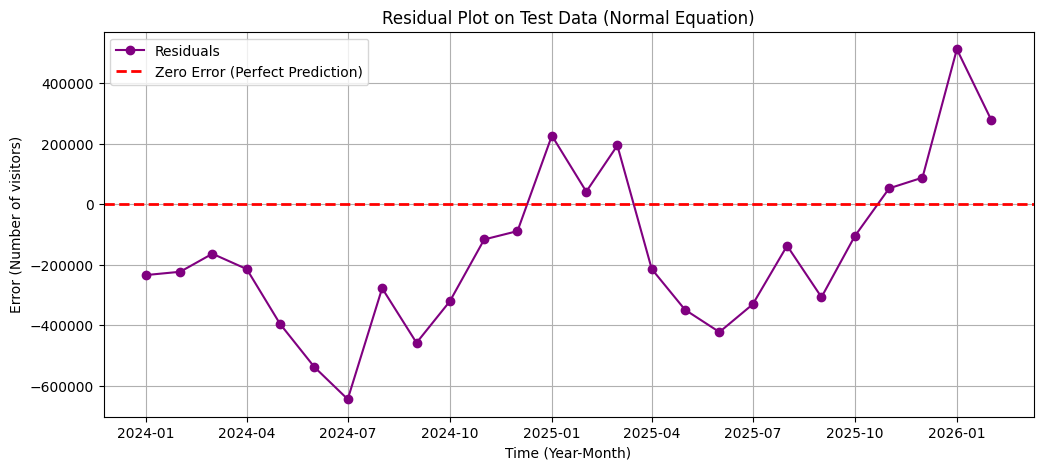

In [21]:
# Calculate residuals for Test Data (Normal Equation)
residuals_test = Y_test_true - Y_test_pred_comb_true

plt.figure(figsize=(12, 5))
# Plot residuals
plt.plot(df_test['date_month_start'], residuals_test, marker='o', color='purple', label='Residuals')
# Plot the zero-error line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error (Perfect Prediction)')

plt.title("Residual Plot on Test Data (Normal Equation)")
plt.xlabel("Time (Year-Month)")
plt.ylabel("Error (Number of visitors)")
plt.legend()
plt.grid(True)
plt.show()

**Residual Analysis Observation:**

In an ideal Linear Regression model, the residuals should be randomly scattered around the zero-error line (red dashed line). However, our residual plot displays a clear **wavy pattern** (pattern of consecutive positive and negative errors)

=>> During **peak seasons**, the model predicts lower figures than reality, and **off-peak seasons**, it predicts higher figures

==> Strongly contribute to our conclusion: LR can be worth-taking for general recovery trend but lacks capacity to capture complex seasonal components

===> The pivotal of upgrading to Time-Series specific models in future work

## **5. Demo Test For New Individual (eg: 3/2026)**

In [22]:
def predict_future_month(t, pos, neg):
    #1. Normalize t, pos, neg
    t_scaled = (t - t_mean) / t_std
    pos_scaled = (pos - pos_mean) / pos_std
    neg_scaled = (neg - neg_mean) / neg_std

    #2. Create Matrix X
    X_matrix = np.array([[1, t_scaled, pos_scaled, neg_scaled]])

    #3. Predict, return real Y
    Y_pred = predict_Y(theta_comb, X_matrix)
    Y_real = inverse_y(Y_pred)

    return int(Y_real.item())
        #item(): retrieve the content

#Predict for 3/2026 (t = 218, pos = 1, neg = 1)
predicted_march = predict_future_month(218, 1, 0)
actual_march = 2080079  #(data from web)

#Calculate errors
error_abs = np.abs(actual_march - predicted_march)
error_percentage = (error_abs * 100) / actual_march

print("=== DEMO FOR 3/2026 ===\n")
print("Normalized Theta:", theta_comb.flatten())
print(f"Predicted number of visitors for 3/2026: {predicted_march:,} visitors")
print(f"Actual number of visitors in 3/2026:     {actual_march:,} visitors")
print(f"Absolute Error:                          {error_abs:,} visitors")
print(f"Percentage Error:                        {error_percentage:.2f}%")

=== DEMO FOR 3/2026 ===

Normalized Theta: [ 0.4841505   0.96150976  0.04438242 -0.02794319]
Predicted number of visitors for 3/2026: 1,958,775 visitors
Actual number of visitors in 3/2026:     2,080,079 visitors
Absolute Error:                          121,304 visitors
Percentage Error:                        5.83%


---

## **Reference Data:**
`international_arrivals_total` (Endogenous Data): https://vietnamtourism.gov.vn/statistic/international

`positive_event_flag`, `negative_event_flag` (Exogenous Data): self-collected features based on real-world historical context (Covid-19, stimulate tourism demand campaigns , economic crisis)